In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from scipy.stats import wasserstein_distance  
from scipy.stats import norm

T = 10
time_steps = np.arange(T)
n_normals = 100
bins = 100
opinion_bins = np.arange(1, bins+1)
bin_edges = np.linspace(0, 1, bins+1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
beta = 10
alpha = 0.1
epsilon = 0.1

def phi(diff, beta):
    return 1 / (1 + np.exp(beta * (abs(diff)-epsilon)))

def simulate_continuous_model( n_normals, T):
    opinions = np.clip(np.random.normal(loc=0.4, scale=0.2, size=n_normals), 0, 1)
    historique = [opinions.copy()]
    for t in range(T):
        total_opinions = np.copy(opinions)
        updated_opinions = np.copy(opinions)
        for i in range(n_normals):
            xi = opinions[i]
            xj = total_opinions
            influence_weights = phi(xi - xj, beta)
            influence_weights[i] = 0 
            sum_weights = np.sum(influence_weights)
            if sum_weights > 0:
                influence = np.sum(influence_weights * (xj - xi)) / sum_weights
                updated_opinions[i] = xi + alpha * influence
        opinions = np.clip(updated_opinions, 0, 1)
        historique.append(opinions.copy())
    return opinions, np.array(historique)



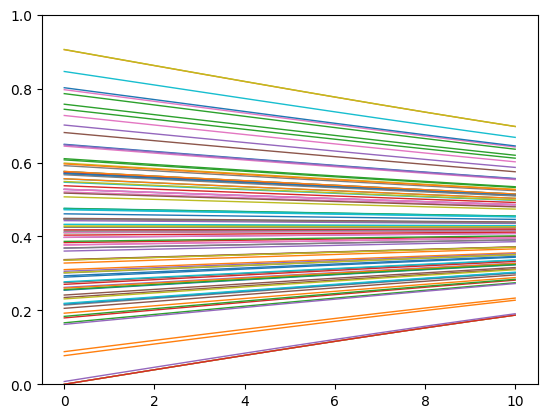

Moyenne des opinions =  0.3904054744454531


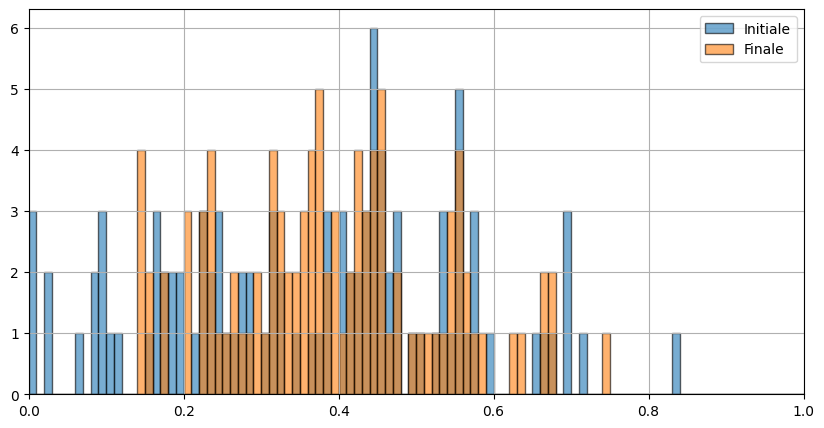

In [42]:
final_opinions = simulate_continuous_model( n_normals, T)[0]
initial_opinions = np.clip(np.random.normal(loc=0.4, scale=0.2, size=n_normals), 0, 1)

def historique():
    historique =simulate_continuous_model(n_normals,T)[1]
    for agent in range(n_normals):
        plt.plot(historique[:, agent],alpha=1, linewidth=1)
    plt.ylim(0, 1)
    plt.show()
historique()

total_opinions = 0
for opinion in final_opinions :
    total_opinions += opinion
print("Moyenne des opinions = ", total_opinions/n_normals)

plt.figure(figsize=(10, 5))
plt.hist(initial_opinions, bins=bin_edges, alpha=0.6, label="Initiale", edgecolor='black', density=True)
plt.hist(final_opinions, bins=bin_edges, alpha=0.6, label="Finale", edgecolor='black', density=True)

plt.legend()
plt.xlim(0, 1)
plt.grid(True)
plt.show()